## Coding Homework 4 - Chapters 6 and 12 - CLRS

### Double-click the cell to add your name here

### 2-15-2026

<mark>___________________________________________________________________________________________________________</mark>

## Coding Tasks Description

The purpose of this coding homework is to practice some coding with array-heaps and linked binary search trees. The tasks here will use skills from the past weeks homework from chapter 10.


**Tasks to complete**
### 1. Implement a min-priority queue with a min-heap.

* You should implement the following methods:
    * MIN-HEAP-EXTRACT-MIN,
    * MIN-HEAP-DECREASE-KEY, and 
    * MIN-HEAP-INSERT.
* You should use the methods from the ```heappriorityqueue``` class and the pseudocode in the textbook as an example.
* This question is based on exercise 6.5-3 of chapter 6 in the CLRS textbook.

### 2. Modify the max heap implementation to have the following two additional methods.

* MAX-HEAP-DECREASE-KEY(A, x, k) method
    * The operation of MAX-HEAP-DECREASE-KEY(A, x, k) adjusts node x to have key k
        * your code should set index x to value k and
        * fix the heap property after the adjustment of x's key
    * This is exercise 6.5-4 from CLRS.
* MAX-HEAP-DELETE(x) method
    * The operation MAX-HEAP-DELETE(A, x) deletes the object x from max-heap A.
    * Your implementation should run in O(lg n) time.
    * This is exercise 6.5-10 from CLRS.

### 3. Implement a $O(n\ \log k)$-time algorithm to merge $k$ sorted lists into one sorted list, where $n$ is the total number of elements in all the input lists.

* This is exercise 6.5-11 from the textbook and is related to a previous paper homeowork #1 question 4(b).
    * The textbook hint is to use a heap of size $k$ to store the elements to merge.
 
### 4. Implement the TREE-PREDECESSOR(x) procedure.

* This is exercise 12.2.3 from the textbook.
* You should base your code on the TREE-SUCCESSOR(x) code and comments in chapter 12 of CLRS.

### 5. Implement the TREE-SUCCESSOR(x) procedure.

* This is exercise 12.2.7 from the textbook.
* You should use the pseudocode from chapter 12 of the CLRS textbook for your implementation.

<mark>___________________________________________________________________________________________________________</mark>

## Load the required notebooks

In [17]:
%%capture
%run Ch6_Heaps.ipynb

In [18]:
%%capture
%run Ch12_BinarySearchTree.ipynb

<mark>___________________________________________________________________________________________________________</mark>

<mark>___________________________________________________________________________________________________________</mark>

## Problems

<mark>_____________________________________________________________________________________</mark>

### 1. Implement a min-priority queue with a min-heap.

The cell below is a template from the code that I implemented when selecting this problem. The three methods you are required to implement are tagged below where you can insert your code to make them work.

The cells at the bottom are the test that I ran on my code to verify that it worked.

In [27]:
class priorityqueue(arraytree):
    """a heap class which is a child of the arraytree class"""

    def __init__(self,n,A=None):
        """constructor for heaps with capacity n"""
        super().__init__(n,A)
        if A:
            self.build_min_heap()
    
    def min(self):
        """removes the min-value from the top of the heap"""
        out = self.A[0]    # min value
        return out
    
    def extract_min(self):
        """removes the min-value from the top of the heap"""
        out = self.A[0]    # min value
        ###########################################
        # insert your code here
        self.A[0] = self.A[self.size - 1]
        self.size = self.size - 1
        self.min_heapify(0)
    
        return out
    
    def min_heap_insert(self,k):
        """insert key k into the min heap"""
        ###########################################
        # insert your code here
        self.size += 1
        i = self.size -  1
        self.A[i] = k

        while (i > 0) and self.A[self.parent(i)] > self.A[i]:
            self.A[i],self.A[self.parent(i)] = self.A[self.parent(i)],self.A[i]
            i = self.parent(i)
        
        return
    
    def min_heapify(self,i):
        """min-heapify algorithm from CLRS chapter 6"""
        
        l = self.left(i)     # left child index
        r = self.right(i)    # right child index
        
        ###########################################
        # insert your code here
        if l < self.size and self.A[l] < self.A[i]:
            smallest = l
        else:
            smallest = i

        if r < self.size and self.A[r] < self.A[smallest]:
            smallest = r

        if smallest != i:
            self.A[i],self.A[smallest] = self.A[smallest],self.A[i]
            self.min_heapify(smallest)

        return
    
    def build_min_heap(self):
        """constructs the heap for array A of size n"""
        for i in range(self.size//2,-1,-1):
            self.min_heapify(i)
    
    def __str__(self):
        """returns a string for text printing purposes"""
        return str(self.A)

[10, 29, 20, 89, 52, 23, 28, 91, None, None, None, None, None, None, None, None]


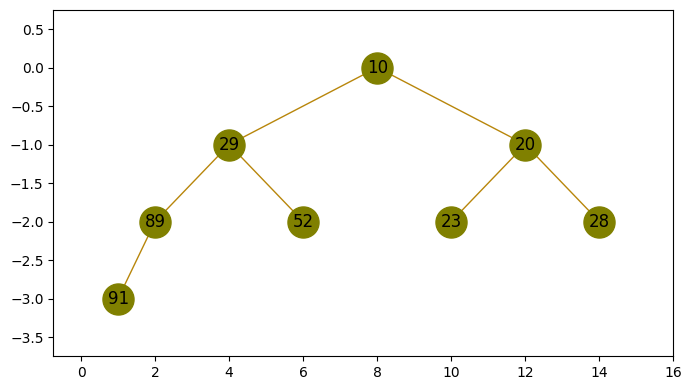

min key = 10


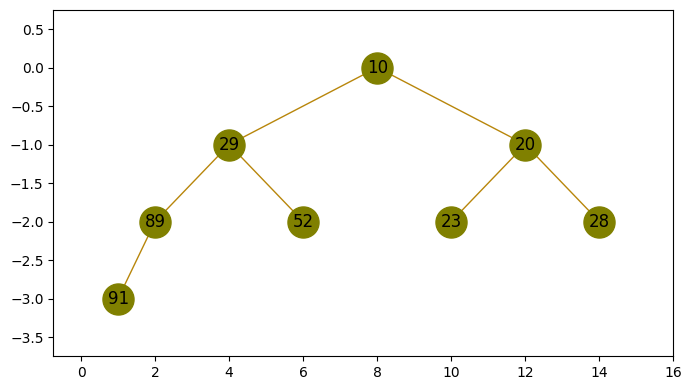

extracting the minimum key
key extracted = 10
updated heap image below


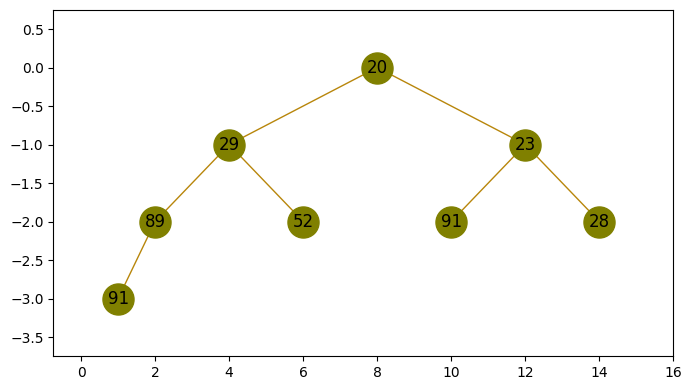

min key = 20


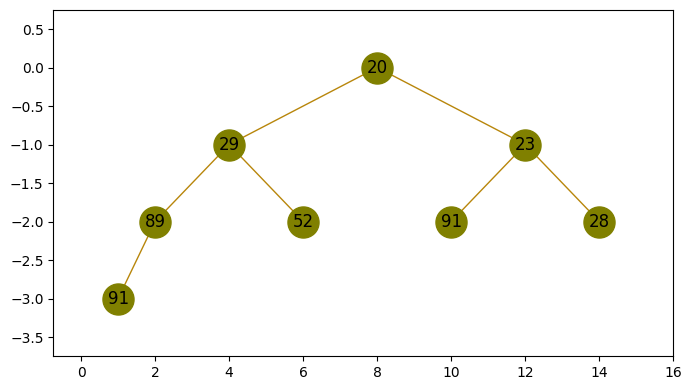

In [28]:
import random

heapPQ = priorityqueue(16)

for i in range(8):
    heapPQ.min_heap_insert(random.randrange(99))
print(heapPQ)
PrintTreeArray(heapPQ)

min_key = heapPQ.min()
print("min key =",min_key)
PrintTreeArray(heapPQ)

print("extracting the minimum key")
min_key = heapPQ.extract_min()
print("key extracted =",min_key)
print("updated heap image below")
PrintTreeArray(heapPQ)

min_key = heapPQ.min()
print("min key =",min_key)
PrintTreeArray(heapPQ)

<mark>_____________________________________________________________________________________</mark>

### 2. Modified max heap implementation

This problem is based on exercises 6.5-4 and 6.5-10 in chapter 6, section 6 of the CLRS textbook. Both methods should run in $O(\log n)$ using techniques similar to the standard heap algorithms (swapping nodes up and down the tree).

In [34]:
class better_max_heap(heap):
    """a heap class which is a child of the arraytree class"""
    
    def max_heap_decrease_key(self,x,k):
        """Adjusts node x to have key k and fixes the heap appropriately"""
        ###########################################
        # insert your code here
        self.A[x] = k
        self.max_heapify(x)
        return

    def max_heap_delete(self,x):
        """deletes node x in O(logn) runtime"""
        ###########################################
        # insert your code here
        self.A[x] = self.A[self.size  - 1]
        self.size = self.size - 1

        if x < self.size:
            if (x > 0) and (self.A[x] > self.A[self.parent(x)]):
                i = x
                while i > 0 and self.A[self.parent(i)] < self.A[i]:
                    self.A[i], self.A[self.parent(i)] = self.A[self.parent(i)],self.A[i]
                    i = self.parent(i)

            else:
                self.max_heapify(x)
        return
    


[3, 9, 4, 8, 1, 2, 6, 5, 10, 0]
[10, 9, 6, 8, 1, 2, 4, 5, 3, 0]


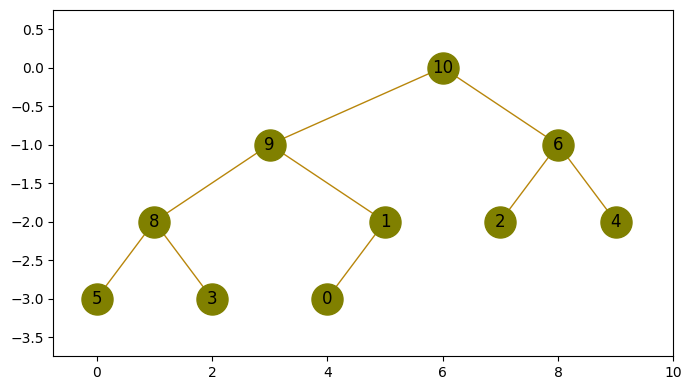

adjusting node at index = 2 to have key = -5
[10, 9, 4, 8, 1, 2, -5, 5, 3, 0]
updated image


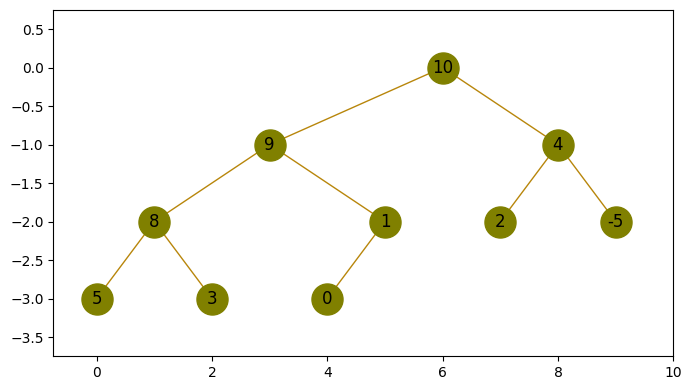

deleting the node at position 1
[10, 8, 4, 5, 1, 2, -5, 0, 3, 0]
updated image


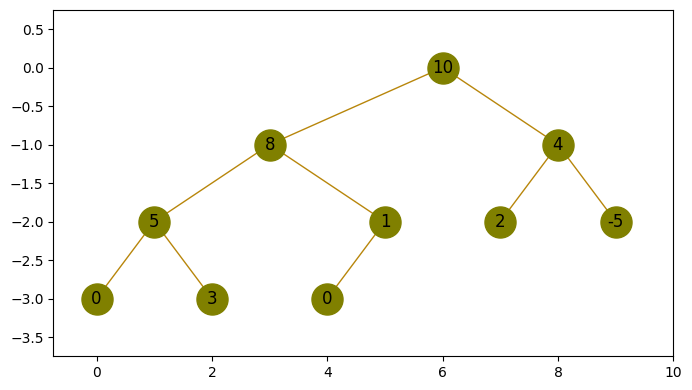

In [35]:
A = [3,9,4,8,1,2,6,5,10,0]
n = len(A)
print(A)

H = better_max_heap(n,A)
print(H)
PrintTreeArray(H)

new_key = -5
idx = 2 # index of node to change the key
print("adjusting node at index =",idx,"to have key =",new_key)
H.max_heap_decrease_key(idx,new_key)
print(H)
print("updated image")
PrintTreeArray(H)

idx2 = 1 # index of node to delete
print("deleting the node at position",idx2)
H.max_heap_delete(idx2)
print(H)
print("updated image")
PrintTreeArray(H)

<mark>_____________________________________________________________________________________</mark>

### 3. Implement a $O(n\ \log k)$-time algorithm to merge $k$ sorted lists into one sorted list, where $n$ is the total number of elements in all the input lists.

*Joys Hint*

To obtain the proper asymptotic runtime, it may help to store an object in each cell of the array and specify how to compare them. In this way, we can obtain the list each item is from in $O(1)$ time (if need be). 

In [36]:
class item:
    """generic item"""
    def __init__(self,k,v):
        """constructor for items"""
        self.key = k
        self.value = v
    
    def __lt__(self,other):
        """key-based comparison"""
        return self.key < other.key


def merge(C,k):
    """merges a collection C of k sorted lists"""
    out = []

    # last hint, I had used the answer to question 1 here
    #H = priorityqueue(k) # create a min-heap of size k (this mean O(log(k))
    
    ###########################################
    # insert your code here

    H = priorityqueue(k)

    for i in range(k):
        if len(C[i]) > 0:
            H.min_heap_insert(item(C[i][0], (i, 0)))
        
    while H.size > 0:
        min_item = H.extract_min()
        out.append(min_item.key)


        i, j = min_item.value 

        if (j + 1 < len(C[i])):
            H.min_heap_insert(item(C[i][j+1], (i,j+1)))
           
        
    return out

In [37]:
def sameQ(A,B):
    """returns True if arrays A and B contain the same values"""
    
    m,n = len(A),len(B)     # compute lengths
    if m!=n: return False   # check if length is the same
    
    for i in range(n):      # loop over elements
        if A[i]!=B[i]: return False # check if they are the same
    
    return True

In [38]:
import random

k = 8

# list of k sorted lists of various lengths
C = [   sorted([random.randrange(99) for i in range(random.randrange(k,2*k))])    for j in range(k)   ]

# call the k-way merge
out = merge(C,k)
print(out)

# construct the answer with python
answer = []        # flat array
for c in C:
    answer += c    # join the arrays
answer.sort()      # python sort
#---------------------------------------------- check answer
if sameQ(answer,out):      # check values
    print("correct!!!")
else:
    print("--------incorrect-------- :'(")

[1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 5, 6, 7, 7, 7, 11, 11, 11, 13, 14, 14, 14, 16, 16, 19, 20, 23, 24, 24, 25, 25, 28, 32, 32, 33, 33, 34, 35, 35, 35, 36, 38, 39, 39, 39, 42, 42, 42, 44, 44, 45, 46, 46, 49, 51, 51, 52, 53, 53, 54, 56, 60, 61, 61, 63, 65, 65, 65, 66, 67, 68, 69, 70, 70, 73, 76, 76, 77, 78, 78, 80, 80, 80, 83, 84, 85, 87, 89, 90, 90, 90, 93, 95, 97]
correct!!!


<mark>_____________________________________________________________________________________</mark>

<mark>_____________________________________________________________________________________</mark>

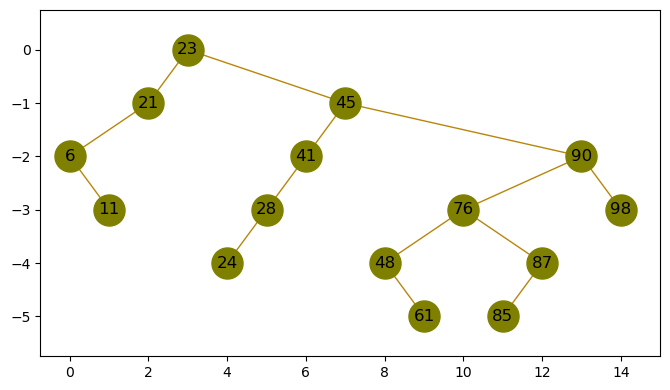

In [71]:
import random

n = 15

BST = binarysearchtree()

keys = []
for i in range(n):
    k = random.randrange(99)
    BST.insert(k)             # call insert
    keys.append(k)
PrintTree(BST)

<mark>_____________________________________________________________________________________</mark>

### 4. 12.2-3 In-order Predecessor

The method ```predecessor(T,x)``` method should return the node from tree $T$ whose key $k$ is the largest key less than or equal to node x's key $x.key$. The recursive method ```tree_max``` is included below which can be used to iterate through the tree $T$ in reverse with the method ```reverse_order(T)``` which prints the keys in reverse order.

In [39]:
def tree_max(T,node):
    """(recursively) find the node with maximum key from the tree T"""
    
    if node.right:
        return tree_max(T,node.right)
    else:
        return node

In [42]:
def predecessor(T,x):
    """returns the in-order predecessor of the node x in tree T"""
    ###########################################
    # insert your code here
    if x.left is not None:
        return tree_max(T,x.left)
    
    y = x.p

    while y is not None and x == y.left:
        x = y
        y = y.p
        
           
    return y 

In [45]:
def reverse_order(T):
    """(non-recursive) in_order traversal of the tree T"""

    x = tree_max(T,T.root)
    
    while x != None:
        print(x.key)
        x = predecessor(T,x)

In [46]:
reverse_order(BST)

73
61
49
44
34
26
23
21
14
5


<mark>_____________________________________________________________________________________</mark>

### 5. In-order Successor

An alternative method of performing an inorder tree walk of an n-node binary search tree finds the minimum element in the tree by calling TREE-MINIMUM and then making n − 1 calls to TREE-SUCCESSOR. Prove that this algorithm runs in Θ(n) time.

In [50]:
def tree_min(T,node):
    """(recursively) find the node with minimum key from the tree T"""
    
    if node.left:
        return tree_min(T,node.left)
    else:
        return node

In [47]:
def successor(T,x):
    """returns the in-order successor of the node x in tree T"""
    ###########################################
    # insert your code here
    
    if x.right is not None:
        return tree_min(T,x.right)
    

    y = x.p

    while y is not None and (x == y.right):
        x = y
        y = y.p

    return y 

In [48]:
def in_order(T):
    """(non-recursive) in_order traversal of the tree T"""

    x = tree_min(T,T.root)
    
    while x != None:
        print(x.key)
        x = successor(T,x)

In [51]:
in_order(BST)

5
14
21
23
26
34
44
49
61
73
